In [25]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import torch

In [26]:
# Load & first look
df=pd.read_csv("sales_data.csv")

In [27]:
# data overview
df

,Date,Product_Category,Quantity,Unit_Price,Total_Revenue,Customer_Age,Payment_Method,Region
0,2025-01-01 00:00:00,Clothing,8,58.60,468.80,53.0,Credit Card,South
1,2025-01-01 01:00:00,Beauty,3,206.73,620.19,51.0,Credit Card,East
2,2025-01-01 02:00:00,Home & Kitchen,8,402.03,3216.24,46.0,Credit Card,North
3,2025-01-01 03:00:00,Home & Kitchen,5,109.98,549.90,41.0,Credit Card,South
4,2025-01-01 04:00:00,Electronics,1,281.99,281.99,41.0,PayPal,West
...,...,...,...,...,...,...,...,...
995,2025-02-11 11:00:00,Electronics,1,470.98,470.98,54.0,PayPal,South
996,2025-02-11 12:00:00,Beauty,5,258.39,1291.95,37.0,Cash,South
997,2025-02-11 13:00:00,Electronics,3,NaN,631.83,20.0,PayPal,North
998,2025-02-11 14:00:00,Beauty,1,407.33,407.33,54.0,NaN,South


In [28]:
# rows & column
df.shape

(1000, 8)

In [29]:
# first 5 rows
df.head()

,Date,Product_Category,Quantity,Unit_Price,Total_Revenue,Customer_Age,Payment_Method,Region
0,2025-01-01 00:00:00,Clothing,8,58.60,468.80,53.0,Credit Card,South
1,2025-01-01 01:00:00,Beauty,3,206.73,620.19,51.0,Credit Card,East
2,2025-01-01 02:00:00,Home & Kitchen,8,402.03,3216.24,46.0,Credit Card,North
3,2025-01-01 03:00:00,Home & Kitchen,5,109.98,549.90,41.0,Credit Card,South
4,2025-01-01 04:00:00,Electronics,1,281.99,281.99,41.0,PayPal,West


In [30]:
# last 5 rows
df.tail()

,Date,Product_Category,Quantity,Unit_Price,Total_Revenue,Customer_Age,Payment_Method,Region
995,2025-02-11 11:00:00,Electronics,1,470.98,470.98,54.0,PayPal,South
996,2025-02-11 12:00:00,Beauty,5,258.39,1291.95,37.0,Cash,South
997,2025-02-11 13:00:00,Electronics,3,NaN,631.83,20.0,PayPal,North
998,2025-02-11 14:00:00,Beauty,1,407.33,407.33,54.0,NaN,South
999,2025-02-11 15:00:00,Clothing,4,419.55,1678.20,57.0,Credit Card,South


In [31]:
# missing value check karna and us ka sum karna baad me 
df.isnull().sum()

Date                 0
Product_Category     0
Quantity             0
Unit_Price          50
Total_Revenue       30
Customer_Age        50
Payment_Method      50
Region               0
dtype: int64

In [32]:
# short stasticle summary
print(df.describe())

          Quantity    Unit_Price  Total_Revenue  Customer_Age
count  1000.000000    950.000000     970.000000    950.000000
mean      5.973000    291.762263    1580.566515     43.326316
std      15.010449    558.484418    4555.523291     15.099628
min       1.000000     10.070000      10.770000     18.000000
25%       3.000000    137.382500     416.512500     31.000000
50%       5.000000    253.585000     969.585000     43.000000
75%       7.000000    381.012500    1974.195000     56.750000
max     300.000000  10000.000000   90000.000000     69.000000


In [33]:
# jojo column me missing value thi vo sab mean & mode se fill karna hai
df['Unit_Price'].fillna(df['Unit_Price'].mean(), inplace=True)    # Number → mean
df['Payment_Method'].fillna(df['Payment_Method'].mode()[0], inplace=True) # Category → mode
df["Total_Revenue"].fillna(df['Total_Revenue'].mean(),inplace=True)  # Number → mean
df["Customer_Age"].fillna(df['Customer_Age'].mean(),inplace=True)   # Number → mean

In [34]:
# firse fillna karne ke baad me  missing value check karna and us ka sum karna baad me 
df.isnull().sum()

Date                0
Product_Category    0
Quantity            0
Unit_Price          0
Total_Revenue       0
Customer_Age        0
Payment_Method      0
Region              0
dtype: int64

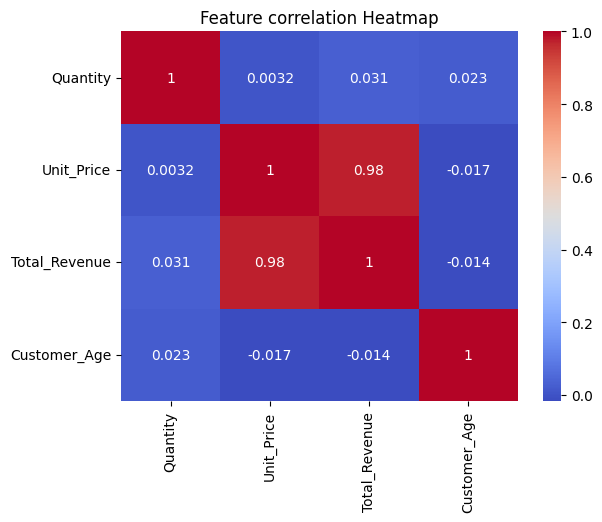

In [35]:
# numerical column ke bich me relation dekhane ke liye heatmap ka use kiya hai 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature correlation Heatmap")
plt.show()

**EDA ke baad pata hona chahiye: dataset size, missing values, distributions, important features, outliers!**

In [36]:
t = torch.tensor([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
print("Original:", t.shape)      # torch.Size([4, 3])

t1 = t.reshape(2, 6)
print("Reshaped:", t1.shape)     # torch.Size([2, 6])

t2 = t.reshape(-1)               # -1 = auto calculate!
print("Flattened:", t2.shape)    # torch.Size([12])

Original: torch.Size([4, 3])
Reshaped: torch.Size([2, 6])
Flattened: torch.Size([12])


In [37]:
x = torch.randn(3, 4)       # 3 samples, 4 features
W = torch.randn(4, 5)       # 4 input → 5 output (layer weights)

# Ye poora neural network layer hai!
output = x @ W              # Ya torch.matmul(x, W)

print("Input:", x.shape)    # torch.Size([3, 4])
print("Weights:", W.shape)  # torch.Size([4, 5])
print("Output:", output.shape) # torch.Size([3, 5])

Input: torch.Size([3, 4])
Weights: torch.Size([4, 5])
Output: torch.Size([3, 5])
